In [3]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import r3b
import ROOT
import seaborn as sns

%jsroot off

### Helper function to compare parameters from different files

In [4]:
def compare_par(par_name, pars):
    plot, axes = plt.subplots()
    axes.set_xticks(np.arange(0, 1301, step=100))
    axes.set_xticks(np.arange(0, 1301, step=50), minor=True)
    axes.tick_params(axis="x", labelsize=13, labelrotation=-30)
    axes.tick_params(axis="y", labelsize=13)
    axes.grid(which="both", axis="x")
    axes.grid(which="minor", alpha=0.5)
    plot.set_size_inches(13, 6)
    for key, value in pars.items():
        value["label"] = key
    # original_pars["label"] = "original"
    # mille_pars["label"] = "millepede"
    # df = pd.concat([original_pars, mille_pars], ignore_index=True)
    df = pd.concat(list(pars.values()), ignore_index=True)
    sns.lineplot(data=df, x="bar_id", y=par_name, ax=axes, hue="label")
    return plot, axes

### Define parameter files with a unique label

Variables to setup:

- `root_path`: the root path used for the calibration of a certain experiment.
- `dir_path`: the subfolder name for a specific test
- `file_maps`: a dictionary with the parameter label as its key and parameter file name as its value

In [5]:
root_path = "/lustre/r3b/ywang/test/s122"
dir_path = "test_aug18"
file_maps = {
    "histogram": "cal2hit.par.root",
    "millepede_0": "millepede.par.root",
    "millepede_1": "millepede.1.par.root",
    "millepede_2": "millepede.2.par.root",
    "recons": "recons.par.root",
}

Read the parameter values from files:

In [6]:
file_readers = {
    label: r3b.neuland.HitParReader(f"{root_path}/{dir_path}/{name}")
    for label, name in file_maps.items()
}
all_pars = {label: reader.read() for label, reader in file_readers.items()}

Number of modules: 1300
Number of modules: 1300
Number of modules: 1300
Number of modules: 1300
Number of modules: 1300


## Parameter comparisons

### Comparison of t_sync parameter

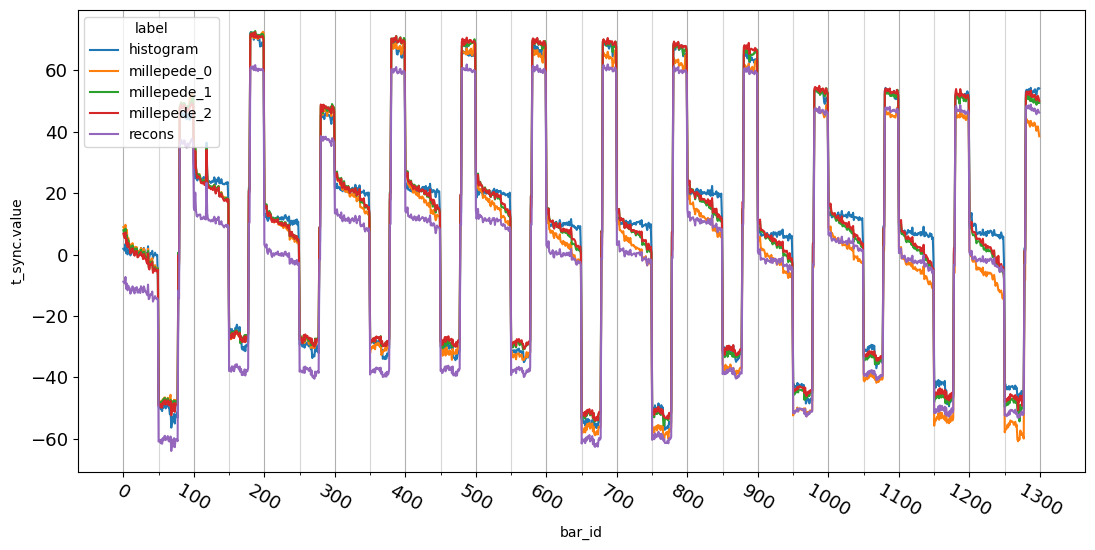

In [4]:
plot, axes = compare_par("t_sync.value", all_pars)
# axes.set(ylim=(-10, 20));
# axes.set(xlim=(1200, 1300))

### Comparison of t_diff parameter

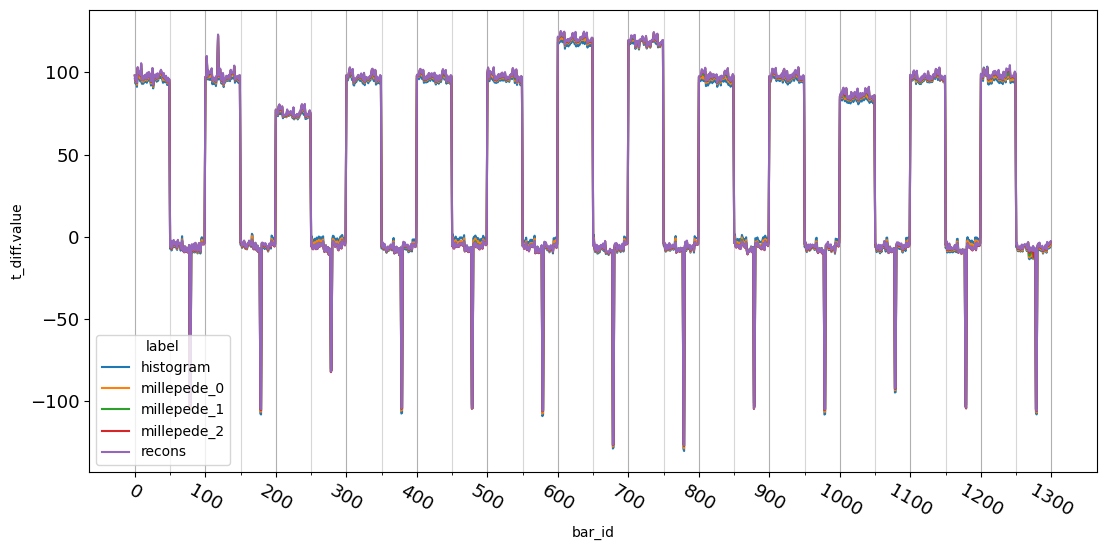

In [5]:
plot, axes = compare_par("t_diff.value", all_pars)
# axes.set(ylim=(-80, 80));

### Comparison of effective speed of light parameter

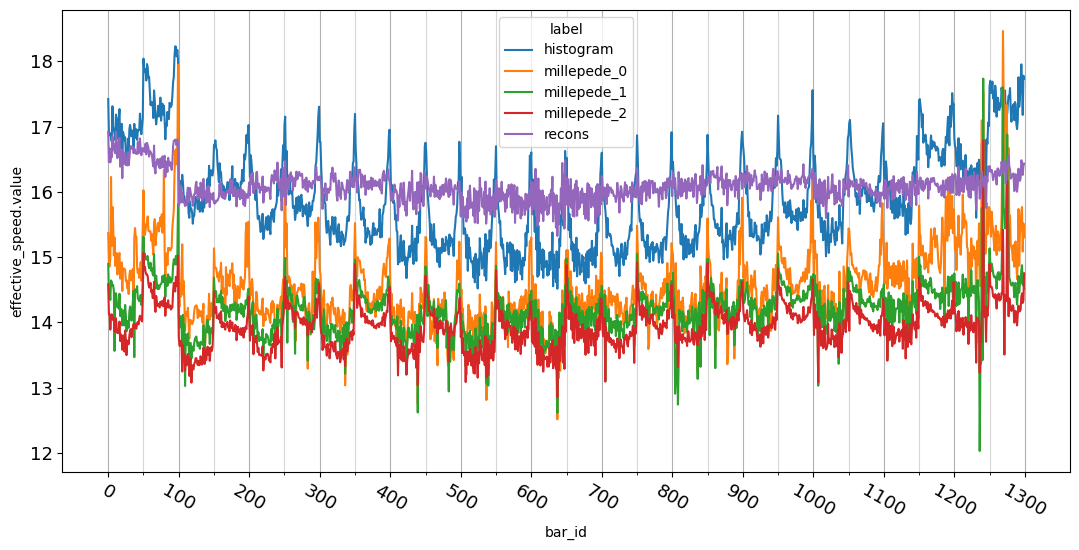

In [6]:
plot, axes = compare_par("effective_speed.value", all_pars)
# axes.set_ylim(10, 25)